# Capítulo 7: Explicabilidad de Modelos de IA (XAI)

**Guía Técnica:** Inteligencia Artificial en Ciberseguridad  
**Mayo 2026**

---

## 7.1. Introducción

Los modelos de ML en seguridad deben ser **explicables** para que los analistas confíen en sus
decisiones y puedan justificarlas ante auditorías.  
**SHAP** (*SHapley Additive exPlanations*) asigna a cada característica una contribución marginal
al resultado de la predicción, fundamentado en la teoría de juegos cooperativos.

### Cadena de dependencias

```
Cap. 04 → random_forest_malware.pkl  ──► SHAP TreeExplainer
Cap. 04 → malware_feature_cols.pkl   ──► nombres de features
Cap. 04 → file_features.csv          ──► dataset de evaluación
```

### Contenido
| Sección | Técnica |
|---|---|
| 7.0 | Carga de modelos y datos del Cap. 04 |
| 7.1 | SHAP global: `summary_plot` |
| 7.2 | SHAP local: `waterfall_plot` por incidente |
| 7.3 | Importancia media de features |

---
## Sección 0: Carga de modelos del Capítulo 04

In [11]:
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from pathlib import Path

MODELS_DIR = Path("../models")
DATA_DIR   = Path("../data")

rf_malware   = joblib.load(MODELS_DIR / "random_forest_malware.pkl")
malware_cols = joblib.load(MODELS_DIR / "malware_feature_cols.pkl")

df_mal = pd.read_csv(DATA_DIR / "file_features.csv")
X      = df_mal[malware_cols]
y      = df_mal["label"]

print("Modelos cargados:")
print(f"  random_forest_malware.pkl  → {type(rf_malware).__name__}")
print(f"  malware_feature_cols.pkl   → {len(malware_cols)} features")
print(f"  file_features.csv          → {len(df_mal):,} muestras")

Modelos cargados:
  random_forest_malware.pkl  → RandomForestClassifier
  malware_feature_cols.pkl   → 12 features
  file_features.csv          → 2,000 muestras


---
## Sección 7.1: SHAP global — `summary_plot`

El **TreeExplainer** calcula los valores SHAP de forma exacta y eficiente para modelos basados
en árboles (Random Forest, XGBoost, etc.).  
El `summary_plot` muestra qué features impactan más en las predicciones y en qué dirección.

In [19]:
# Usamos una muestra representativa para acelerar el cálculo
X_sample = X.sample(n=min(500, len(X)), random_state=42).reset_index(drop=True)

explainer   = shap.TreeExplainer(rf_malware)
shap_values = explainer.shap_values(X_sample)   # shape: [n_classes, n_samples, n_features]

# shap_values[1] → clase 1 (malware)
shap_malware = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

print(f"SHAP calculado: {shap_malware.shape[0]} muestras × {shap_malware.shape[1]} features")

SHAP calculado: 500 muestras × 12 features


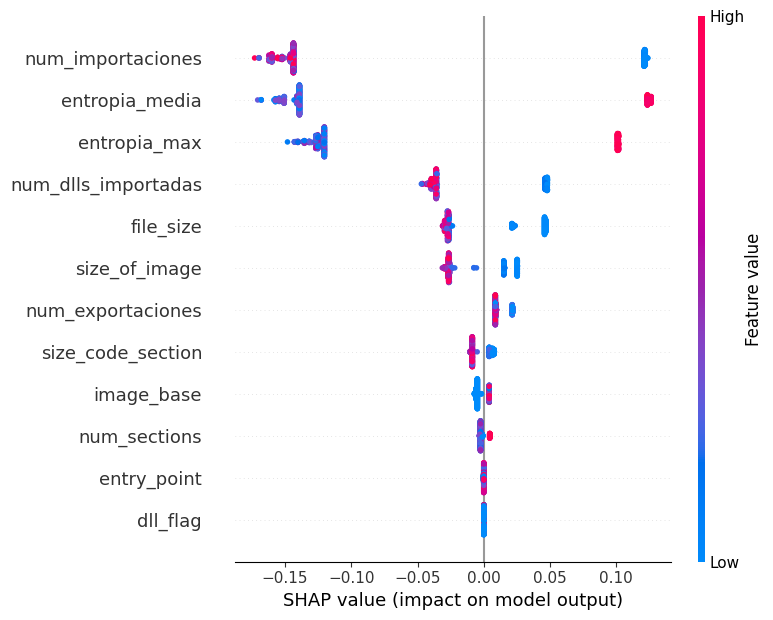

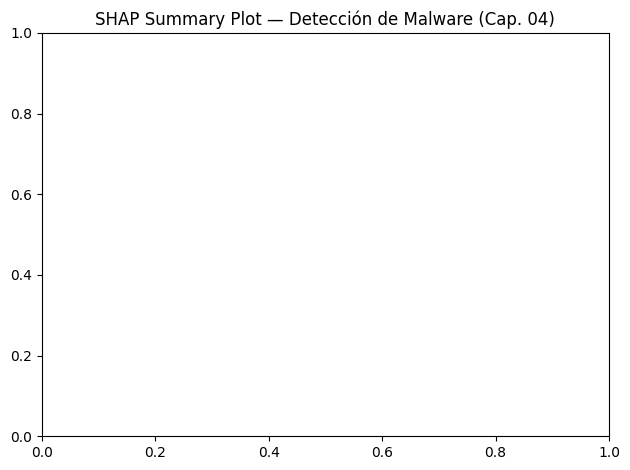

In [20]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_malware, X_sample,
    feature_names=malware_cols,
    plot_type="dot",
    # show=False
)
plt.title("SHAP Summary Plot — Detección de Malware (Cap. 04)")
plt.tight_layout()
plt.savefig(DATA_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

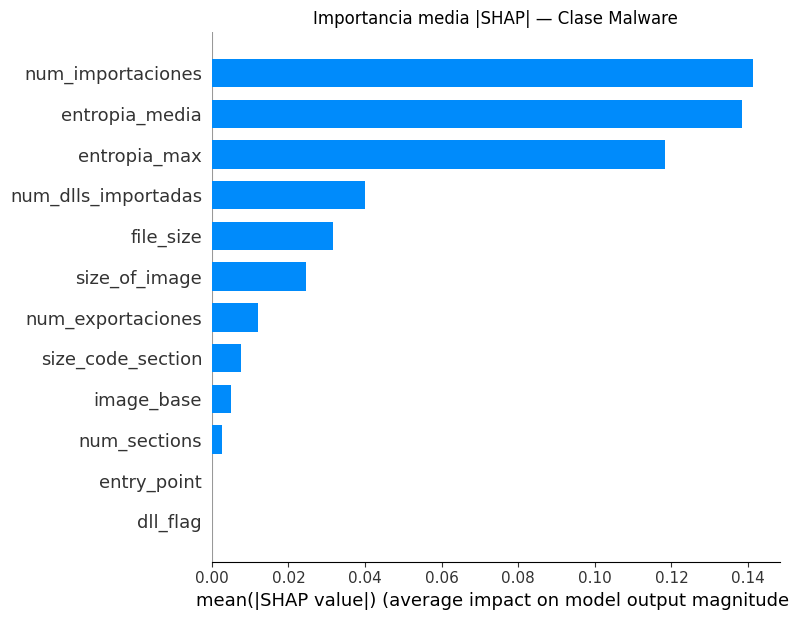

In [21]:
# Bar plot: importancia media |SHAP|
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_malware, X_sample,
    feature_names=malware_cols,
    plot_type="bar",
    show=False
)
plt.title("Importancia media |SHAP| — Clase Malware")
plt.tight_layout()
plt.savefig(DATA_DIR / "shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Sección 7.2: SHAP local — Explicación por incidente

El **waterfall plot** muestra cómo cada feature empuja la predicción desde el valor base
($E[f(x)]$) hasta el valor final para una muestra específica.

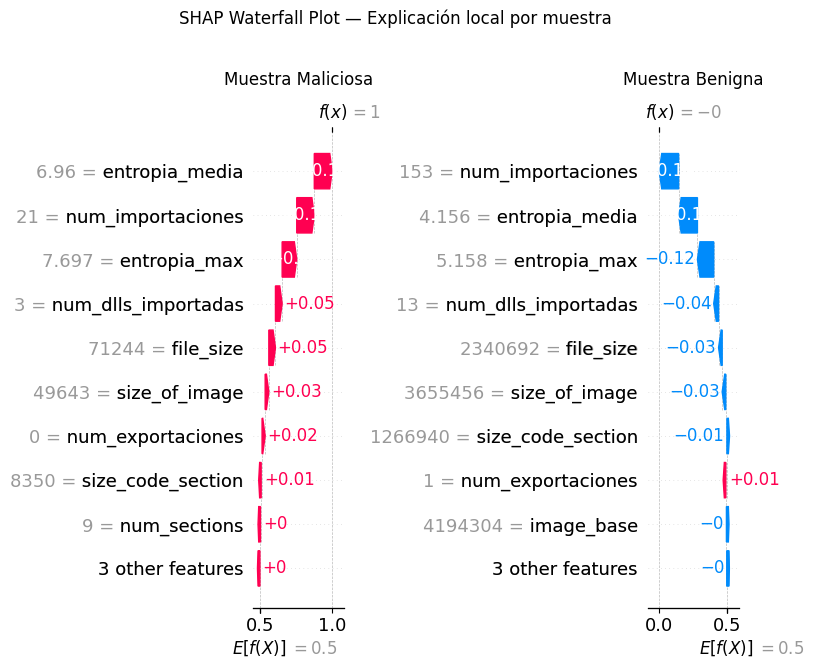

In [22]:
# Seleccionamos una muestra maliciosa y una benigna
idx_mal = X_sample.index[X_sample.index.isin(y[y == 1].index)]
idx_ben = X_sample.index[X_sample.index.isin(y[y == 0].index)]

# Tomamos el primer índice disponible de cada clase en la muestra
i_mal = int(df_mal[df_mal.label == 1].index[0])
i_ben = int(df_mal[df_mal.label == 0].index[0])

# Recalculamos SHAP para esas dos muestras individuales
X_local = X.iloc[[i_mal, i_ben]]
sv_local = explainer(X_local)     # Explanation object para waterfall

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, idx_local, titulo in [
    (axes[0], 0, "Muestra Maliciosa"),
    (axes[1], 1, "Muestra Benigna"),
]:
    plt.sca(ax)
    shap.plots.waterfall(sv_local[idx_local, :, 1], max_display=10, show=False)
    ax.set_title(titulo, pad=12)

plt.suptitle("SHAP Waterfall Plot — Explicación local por muestra", y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Sección 7.3: Ranking de importancia de features

Comparamos la importancia SHAP con la importancia nativa de Random Forest (`feature_importances_`).

=== Ranking de importancia de features ===
            feature  shap_mean  rf_native
  num_importaciones    0.14129    0.24448
     entropia_media    0.13848    0.24440
       entropia_max    0.11832    0.20033
num_dlls_importadas    0.03988    0.08950
          file_size    0.03169    0.09076
      size_of_image    0.02463    0.06614
  num_exportaciones    0.01196    0.03933
  size_code_section    0.00764    0.01767
         image_base    0.00497    0.00443
       num_sections    0.00276    0.00295
        entry_point    0.00006    0.00001
           dll_flag    0.00000    0.00000


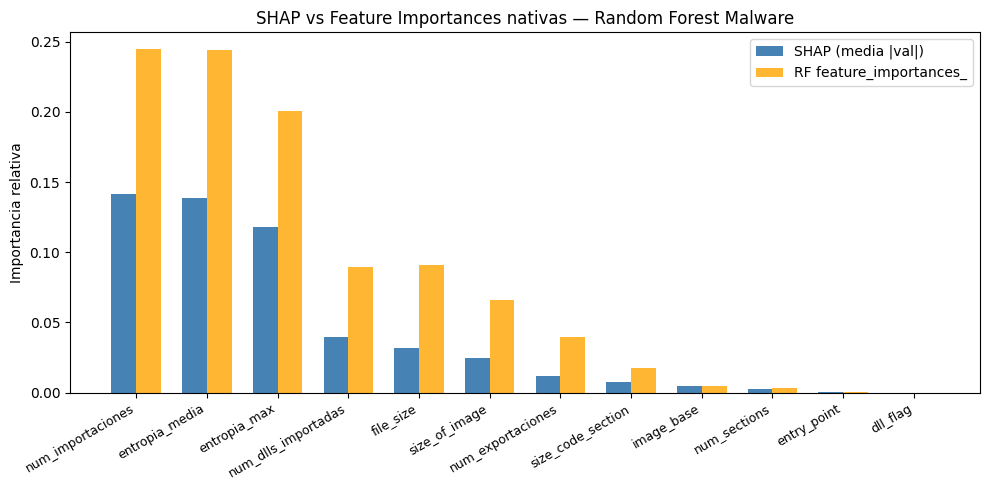

In [23]:
# Importancia media |SHAP|
shap_importance = np.abs(shap_malware).mean(axis=0)
rf_importance   = rf_malware.feature_importances_

imp_df = pd.DataFrame({
    "feature"   : malware_cols,
    "shap_mean" : shap_importance,
    "rf_native"  : rf_importance,
}).sort_values("shap_mean", ascending=False).reset_index(drop=True)

print("=== Ranking de importancia de features ===")
print(imp_df.to_string(index=False, float_format="{:.5f}".format))

# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(imp_df))
w = 0.35
ax.bar(x - w/2, imp_df["shap_mean"], w, label="SHAP (media |val|)",  color="steelblue")
ax.bar(x + w/2, imp_df["rf_native"],  w, label="RF feature_importances_", color="orange", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(imp_df["feature"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Importancia relativa")
ax.set_title("SHAP vs Feature Importances nativas — Random Forest Malware")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "shap_vs_rf.png", dpi=150)
plt.show()

---
**Siguiente:** Capítulo 8 → Ataques Adversariales contra Modelos de IA